In [16]:
import sys
from pathlib import Path
base_path = Path('..')
sys.path.insert(0, str(base_path))

In [17]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mtrans
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score  
import warnings 
warnings.filterwarnings(action='ignore')

from erasers import *

import seaborn as sns




In [18]:
# a function to generate a centered mixture of 2 gaussians 
def generate_gaussian_mixture(n_samples=2000, mean1=[0,0], mean2=[5,5], cov1=[[1,0],[0,1]], cov2=[[1,0],[0,1]], random_state=42):
    np.random.seed(random_state)
    samples1 = np.random.multivariate_normal(mean1, cov1, n_samples//2)
    samples2 = np.random.multivariate_normal(mean2, cov2, n_samples//2)
    samples = np.vstack((samples1, samples2))
    # center the data
    samples = samples - samples.mean(axis=0)
    # shuffle the samples
    np.random.shuffle(samples)
    return samples


# Synthetic data with near perfect concept predictability (High separability)

In [19]:
# Generate a dataset
samples1 = generate_gaussian_mixture(n_samples=1000, mean1=[-2,2], mean2=[-4,3], cov1=[[1,0],[0,1]], cov2=[[0.5,0.2],[0.2,0.5]], random_state=42)
samples2 = generate_gaussian_mixture(n_samples=1000, mean1=[-1.5,2], mean2=[-3.5,2.5], cov1=[[0.9,0.1],[0.1,0.9]], cov2=[[0.4,0.1],[0.1,0.4]], random_state=42)
translation = np.array([2.0, 0]) # translation vector for shifting the Gaussian mixtures
samples1 -= translation
samples2 += translation

x = np.concatenate((samples1, samples2), axis=0)
z = np.array([0]*(len(samples1)) + [1]*(len(samples2))) # binary sensitive attribute indicating which gaussian the sample belongs to
# shuffle the samples and labels together
perm = np.random.permutation(len(x))
x, z = x[perm], z[perm]

xH, xH_test, zH, zH_test = train_test_split(x, z, test_size=0.2, random_state=123)
print("Majority class proportion:", max(sum(z==0), sum(z==1))/len(z))


Majority class proportion: 0.5


In [20]:
# train a MLP classifier to predict z from x
clf = MLPClassifier(random_state=42, validation_fraction=0.1, early_stopping=True).fit(xH, zH)
z_pred = clf.predict(xH_test)
acc = accuracy_score(zH_test, z_pred)
print(f"Probing accuracy for predicting z from x: {acc:.4f}")

Probing accuracy for predicting z from x: 0.9450


In [21]:
erasure_model = MUtE(nsteps=20)
erasure_model.fit(xH,zH)
xH_ = erasure_model.transform(xH)
xH_test_ = erasure_model.transform(xH_test)
routing_clfH = erasure_model.class_clf
accuracy_originalH = accuracy_score(zH_test, routing_clfH.predict(xH_test))

Class predictor trained with accuracy (on train set): 0.94875


Iteration 20/20 complete.: 100%|██████████| 20/20 [00:00<00:00, 301.42it/s]


In [22]:
# train a MLP classifier to predict z from x_
clfH_erased = MLPClassifier(random_state=42, validation_fraction=0.1, early_stopping=True).fit(xH_, zH)
z_pred = clfH_erased.predict(xH_test_)
acc = accuracy_score(zH_test, z_pred)
print(f"Probing accuracy after erasure for predicting z from x: {acc:.4f}")

Probing accuracy after erasure for predicting z from x: 0.4750


In [23]:
# Generate the counterfactual representations
xH_cf = erasure_model.inverse_transform(xH_, 1 - erasure_model.class_clf.predict(xH))
z_filter = zH == erasure_model.class_clf.predict(xH)
xH_cf_filtered = xH_cf[z_filter]
zH_filtered = zH[z_filter]
xH_filtered = xH[z_filter]


# Synthetic data with non-negligible routing error (Low separability)

In [24]:
# Generate a dataset
samples1 = generate_gaussian_mixture(n_samples=1000, mean1=[-2,2], mean2=[-4,3], cov1=[[1,0],[0,1]], cov2=[[0.5,0.2],[0.2,0.5]], random_state=42)
samples2 = generate_gaussian_mixture(n_samples=1000, mean1=[-1.5,2], mean2=[-3.5,2.5], cov1=[[0.9,0.1],[0.1,0.9]], cov2=[[0.4,0.1],[0.1,0.4]], random_state=42)
translation = np.array([1.2, 0]) # translation vector for shifting the Gaussian mixtures
samples1 -= translation
samples2 += translation

x = np.concatenate((samples1, samples2), axis=0)
z = np.array([0]*(len(samples1)) + [1]*(len(samples2))) # binary sensitive attribute indicating which gaussian the sample belongs to
# shuffle the samples and labels together
perm = np.random.permutation(len(x))
x, z = x[perm], z[perm]

xL, xL_test, zL, zL_test = train_test_split(x, z, test_size=0.2, random_state=123)
print("Majority class proportion:", max(sum(z==0), sum(z==1))/len(z))


Majority class proportion: 0.5


In [25]:
# train a MLP classifier to predict z from x
clf = MLPClassifier(random_state=42, validation_fraction=0.1, early_stopping=True).fit(xL, zL)
z_pred = clf.predict(xL_test)
acc = accuracy_score(zL_test, z_pred)
print(f"Probing accuracy for predicting z from x: {acc:.4f}")

Probing accuracy for predicting z from x: 0.8125


In [26]:
erasure_model = MUtE(nsteps=20, alpha=1e-10)
erasure_model.fit(xL,zL)
xL_ = erasure_model.transform(xL)
xL_test_ = erasure_model.transform(xL_test)
routing_clfL = erasure_model.class_clf
accuracy_originalL = accuracy_score(zL_test, routing_clfL.predict(xL_test))

Class predictor trained with accuracy (on train set): 0.82875


Iteration 20/20 complete.: 100%|██████████| 20/20 [00:00<00:00, 307.83it/s]


In [27]:
# train a MLP classifier to predict z from x_
clfL_erased = MLPClassifier(random_state=42, validation_fraction=0.1, early_stopping=True).fit(xL_, zL)
z_pred = clfL_erased.predict(xL_test_)
acc = accuracy_score(zL_test, z_pred)
print(f"Probing accuracy after erasure for predicting z from x: {acc:.4f}")

Probing accuracy after erasure for predicting z from x: 0.5525


In [28]:
# Generate the counterfactual representations
xL_cf = erasure_model.inverse_transform(xL_, 1 - erasure_model.class_clf.predict(xL))
z_filter = zL == erasure_model.class_clf.predict(xL)
xL_cf_filtered = xL_cf[z_filter]
zL_filtered = zL[z_filter]
xL_filtered = xL[z_filter]


# Visualization

In [29]:
eps = 0.2
# We need to display xH, xL, xH counterfactuals and xL counterfactuals
# So we need to calculate the minimal/maximal x and y axis values of these four sets of points: xH, xL, xH counterfactuals, and xL counterfactuals
x0_min = min(xH[:,0].min(), xL[:,0].min(), xH_cf[:,0].min(), xL_cf[:,0].min())-eps
x0_max = max(xH[:,0].max(), xL[:,0].max(), xH_cf[:,0].max(), xL_cf[:,0].max())+eps
x1_min = min(xH[:,1].min(), xL[:,1].min(), xH_cf[:,1].min(), xL_cf[:,1].min())-eps
x1_max = max(xH[:,1].max(), xL[:,1].max(), xH_cf[:,1].max(), xL_cf[:,1].max())+eps

# We will also display on a separate subplot the erased versions of xH and xL
# So we need to calculate the minimal/maximal x and y axis values of these two sets of points: xH erased and xL erased
x0_min_erased = min(xH_[:,0].min(), xL_[:,0].min())-eps
x0_max_erased = max(xH_[:,0].max(), xL_[:,0].max())+eps
x1_min_erased = min(xH_[:,1].min(), xL_[:,1].min())-eps
x1_max_erased = max(xH_[:,1].max(), xL_[:,1].max())+eps


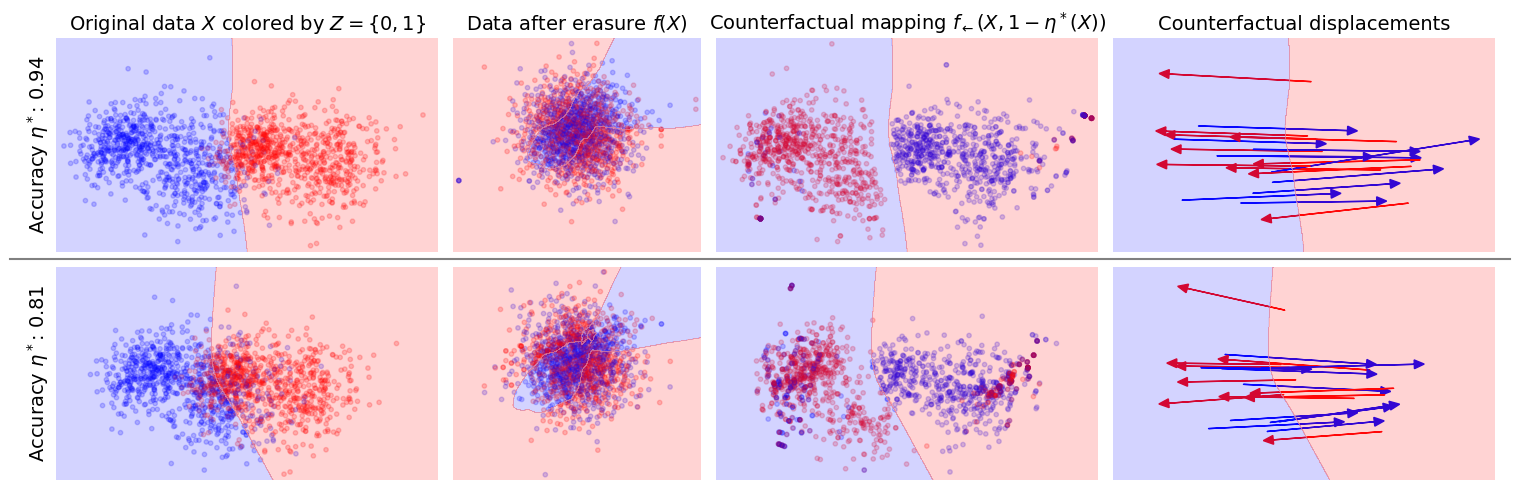

In [30]:

# let us define the figure and the subplots
fig, axes = plt.subplots(2, 4, figsize=(15, 5), width_ratios=[1,0.65,1,1], height_ratios=[1,1])
axes_shape = axes.shape
# make the 2nd subplot a square one with equal aspect ratio

axes = axes.flatten()  # Flatten the 2x4 array of axes for easier indexing
# axes[1].set_aspect('equal', 'box')
# axes[5].set_aspect('equal', 'box')
cmap = "bwr"

# original Highly separable data
axes[0].scatter(xH[:,0], xH[:,1], c=zH, alpha=0.2, s=10, cmap=cmap)
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 1000), np.linspace(x1_min, x1_max, 1000))
Z = routing_clfH.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape) 
axes[0].contourf(xx, yy, Z, alpha=0.2, cmap=cmap)
axes[0].set_xlim(x0_min, x0_max)
axes[0].set_ylim(x1_min, x1_max)

# Highly separable data after erasure
axes[1].scatter(xH_[:,0], xH_[:,1], c=zH, alpha=0.2, s=10, cmap=cmap)
xx, yy = np.meshgrid(np.linspace(x0_min_erased, x0_max_erased, 1000), np.linspace(x1_min_erased, x1_max_erased, 1000))
Z = clfH_erased.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape) 
axes[1].contourf(xx, yy, Z, alpha=0.2, cmap=cmap)
axes[1].set_xlim(x0_min_erased, x0_max_erased)
axes[1].set_ylim(x1_min_erased, x1_max_erased)



# Counterfactual Highly separable data
axes[2].scatter(xH_cf[:,0], xH_cf[:,1], c=zH, alpha=0.2, s=10, cmap=cmap)
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 1000), np.linspace(x1_min, x1_max, 1000))
Z = routing_clfH.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape) 
axes[2].contourf(xx, yy, Z, alpha=0.2, cmap=cmap)
axes[2].set_xlim(x0_min, x0_max)
axes[2].set_ylim(x1_min, x1_max)

# Displacement between original Highly separable data and their counterfactuals (using arrows and the filtered correctly predicted samples)
# Select 20 correctly predicted samples for visualization (10 per class) using "filtered" data
zH_filtered_10_0 = zH_filtered[zH_filtered == 0][:10]
zH_filtered_10_1 = zH_filtered[zH_filtered == 1][:10]
xH_filtered_10_0 = xH_filtered[zH_filtered == 0][:10]
xH_filtered_10_1 = xH_filtered[zH_filtered == 1][:10]
xH_cf_filtered_10_0 = xH_cf_filtered[zH_filtered == 0][:10]
xH_cf_filtered_10_1 = xH_cf_filtered[zH_filtered == 1][:10]

# Plot the displacement arrows for the filtered samples
for i in range(10):
    axes[3].arrow(xH_filtered_10_0[i,0], xH_filtered_10_0[i,1], xH_cf_filtered_10_0[i,0]-xH_filtered_10_0[i,0], xH_cf_filtered_10_0[i,1]-xH_filtered_10_0[i,1], color='blue', alpha=1.0, head_width=0.3, head_length=0.3)
    axes[3].arrow(xH_filtered_10_1[i,0], xH_filtered_10_1[i,1], xH_cf_filtered_10_1[i,0]-xH_filtered_10_1[i,0], xH_cf_filtered_10_1[i,1]-xH_filtered_10_1[i,1], color='red', alpha=1.0, head_width=0.3, head_length=0.3)
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 1000), np.linspace(x1_min, x1_max, 1000))
Z = routing_clfH.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape) 
axes[3].contourf(xx, yy, Z, alpha=0.2, cmap=cmap)
axes[3].set_xlim(x0_min, x0_max)
axes[3].set_ylim(x1_min, x1_max)



# original Low separable data
axes[4].scatter(xL[:,0], xL[:,1], c=zL, alpha=0.2, s=10, cmap=cmap)
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 1000), np.linspace(x1_min, x1_max, 1000))
Z = routing_clfL.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape) 
axes[4].contourf(xx, yy, Z, alpha=0.2, cmap=cmap)
axes[4].set_xlim(x0_min, x0_max)
axes[4].set_ylim(x1_min, x1_max)


# Low separable data after erasure
axes[5].scatter(xL_[:,0], xL_[:,1], c=zL, alpha=0.2, s=10, cmap=cmap)
xx, yy = np.meshgrid(np.linspace(x0_min_erased, x0_max_erased, 1000), np.linspace(x1_min_erased, x1_max_erased, 1000))
Z = clfL_erased.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape) 
axes[5].contourf(xx, yy, Z, alpha=0.2, cmap=cmap)
axes[5].set_xlim(x0_min_erased, x0_max_erased)
axes[5].set_ylim(x1_min_erased, x1_max_erased)

# Counterfactual Low separable data
axes[6].scatter(xL_cf[:,0], xL_cf[:,1], c=zL, alpha=0.2, s=10, cmap=cmap)
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 1000), np.linspace(x1_min, x1_max, 1000))
Z = routing_clfL.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape) 
axes[6].contourf(xx, yy, Z, alpha=0.2, cmap=cmap)
axes[6].set_xlim(x0_min, x0_max)
axes[6].set_ylim(x1_min, x1_max)

# Displacement between original Low separable data and their counterfactuals (using arrows and the filtered correctly predicted samples)
# Select 20 correctly predicted samples for visualization (10 per class) using "filtered" data
zL_filtered_10_0 = zL_filtered[zL_filtered == 0][:10]
zL_filtered_10_1 = zL_filtered[zL_filtered == 1][:10]
xL_filtered_10_0 = xL_filtered[zL_filtered == 0][:10]
xL_filtered_10_1 = xL_filtered[zL_filtered == 1][:10]
xL_cf_filtered_10_0 = xL_cf_filtered[zL_filtered == 0][:10]
xL_cf_filtered_10_1 = xL_cf_filtered[zL_filtered == 1][:10]

# Plot the displacement arrows for the filtered samples
for i in range(10):
    axes[7].arrow(xL_filtered_10_0[i,0], xL_filtered_10_0[i,1], xL_cf_filtered_10_0[i,0]-xL_filtered_10_0[i,0], xL_cf_filtered_10_0[i,1]-xL_filtered_10_0[i,1], color='blue', alpha=1.0, head_width=0.3, head_length=0.3)
    axes[7].arrow(xL_filtered_10_1[i,0], xL_filtered_10_1[i,1], xL_cf_filtered_10_1[i,0]-xL_filtered_10_1[i,0], xL_cf_filtered_10_1[i,1]-xL_filtered_10_1[i,1], color='red', alpha=1.0, head_width=0.3, head_length=0.3)
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 1000), np.linspace(x1_min, x1_max, 1000))
Z = routing_clfL.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape) 
axes[7].contourf(xx, yy, Z, alpha=0.2, cmap=cmap)
axes[7].set_xlim(x0_min, x0_max)
axes[7].set_ylim(x1_min, x1_max)


# don't display the axis ticks and labels
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)  
    ax.spines['left'].set_visible(False)

# Add a title to axis 0
fontsize = 14
axes[0].set_title("Original data $X$ colored by $Z=\{0,1\}$", fontsize=fontsize)
axes[1].set_title("Data after erasure $f(X)$", fontsize=fontsize)
axes[2].set_title("Counterfactual mapping $f_{\leftarrow}(X, 1-\eta^*(X))$", fontsize=fontsize)
axes[3].set_title("Counterfactual displacements", fontsize=fontsize)
# Add a y axis label to axis 0
axes[0].set_ylabel(f"Accuracy $\eta^*$: {accuracy_originalH:.2f}", fontsize=fontsize)
axes[4].set_ylabel(f"Accuracy $\eta^*$: {accuracy_originalL:.2f}", fontsize=fontsize)


fig.tight_layout()  # Adjust the layout to make room for the horizontal line

# Draw an horizontal line
r = fig.canvas.get_renderer()
get_bbox = lambda ax: ax.get_tightbbox(r).transformed(fig.transFigure.inverted())
bboxes = np.empty(len(axes), dtype=object)
for i, ax in enumerate(axes):
    bboxes[i] = get_bbox(ax)
bboxes = bboxes.reshape(axes_shape)
#Get the minimum and maximum extent, get the coordinate half-way between those
ymax = np.array(list(map(lambda b: b.y1, bboxes.flat))).reshape(axes_shape).max(axis=1)
ymin = np.array(list(map(lambda b: b.y0, bboxes.flat))).reshape(axes_shape).min(axis=1)
ys = np.c_[ymax[1:], ymin[:-1]].mean(axis=1)
for y in ys:
    line = plt.Line2D([0,1],[y,y], transform=fig.transFigure, color="grey")
    fig.add_artist(line)

